<a href="https://colab.research.google.com/github/brazzzino/Programacao-oo/blob/main/Ci%C3%AAncia_de_Dados_Aplicados_Estudo_Dirigido_01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div align="center">

**UNIVERSIDADE TUIUTI DO PARANÁ**

<br>

**CAIO FEDERICO ESQUIVEL LOVERA ARZE**

**DOUGLAS CLAYTON DA SILVA**

**FERNANDO BACH**

**LUCAS TOTEROL RODRIGUES**

<br><br><br><br><br><br>

**K-NEAREST NEIGHBORS**

</div>

<br>

</div> <br> <div align="right"> Trabalho apresentado ao quarto período do Curso de<br> Análise e Desenvolvimento de Sistemas, como requisito<br> avaliativo da disciplina de Ciência de Dados Aplicada. <br><br> Orientador: Sergio Luiz Marques Filho
</div>

<br><br><br><br><br><br>

<div align="center">

**CURITIBA**

**2026**

</div>

Realizadas as importações das bibliotecas necessárias e o upload do arquivo apples_and_orange.csv, feito a alteração do nome das colunas para português.

In [94]:
import pandas as pd # lê o CSV e organiza os dados em tabela (DataFrame)
import matplotlib.pyplot as plt # desenha o gráfico de dispersão do item A
import seaborn as sns # desenha a matriz de confusão como mapa de calor
import io # converte o arquivo enviado em algo que o pandas consegue ler
from google.colab import files # abre a janela para enviar o CSV pelo navegador
from sklearn.model_selection import train_test_split # separa a base em treino (80%) e teste (20%)
from sklearn.preprocessing import StandardScaler  # coloca peso e tamanho na mesma escala, já que o KNN decide por distância
from sklearn.neighbors import KNeighborsClassifier # o classificador KNN em si
from sklearn.metrics import accuracy_score # calcula o percentual de acertos do modelo
from sklearn.metrics import confusion_matrix # monta a tabela de acertos e erros por classe

In [95]:
uploaded = files.upload()
df = pd.read_csv(io.BytesIO(uploaded['apples_and_oranges.csv'])) # o nome do arquivo tem que ser colocado o .csv junto
df.columns = ['peso','tamanho','classe']

Saving apples_and_oranges.csv to apples_and_oranges.csv


df.head para conferir se o arquivo foi carregado corretamente, conforme comentado em aula pelo professor nunca exibir a base inteira, sempre de 10 a 20 linhas.

In [96]:
df.head(10)

,peso,tamanho,classe
0,69,4.39,orange
1,69,4.21,orange
2,65,4.09,orange
3,72,5.85,apple
4,67,4.70,orange
5,73,5.68,apple
6,70,5.56,apple
7,75,5.11,apple
8,74,5.36,apple
9,65,4.27,orange


Primeiro foi aplicado o código abaixo sobre a coluna classe que retornou 20 laranjas e 20 maçãs. Confirmando assim, o balanceamento da base, em bases desbalanceadas a acurácia pode indicar bom desempenho mesmo em modelos que não aprenderam nada.

In [97]:
print(df['classe'].value_counts())

classe
orange    20
apple     20
Name: count, dtype: int64


Para verificar as estatísticas de uma vez, foi utilizado o df.describe() conforme comentado em aula. Com o count verificamos que não há valores nulos. O peso varia de 65 a 75, com média de 70,20 e desvio padrão de  3,03. O tamanho varia de 4,01 a 5,85, com média de 4,92 e desvio padrão de 0,59. A diferença que existe entre o desvio padrão do peso e do tamanho pode impactar no resultado.

In [98]:
print(df.describe())

            peso    tamanho
count  40.000000  40.000000
mean   70.200000   4.922750
std     3.039906   0.590063
min    65.000000   4.010000
25%    68.000000   4.360000
50%    70.000000   4.930000
75%    73.000000   5.472500
max    75.000000   5.850000


Aqui foram verificado valores nulos nas colunas e verificado também linha repetida/duplicada. Retornou valores zerados, não sendo necessária etapa de limpeza.

In [99]:
print(df.isnull().sum())        # células vazias por coluna
print('Duplicadas:',df.duplicated().sum())    # linhas repetidas

peso       0
tamanho    0
classe     0
dtype: int64
Duplicadas: 0


Gerado gráfico de dispersão relacionando o peso e o tamanho com as classes diferenciadas por cor.
Analisando o gráfico, conseguimos ver que as laranjas e as maçãs ocupam regiões diferentes, isso por conta da laranja ter menor peso e tamanho, enquanto as maçãs são o oposto, exceto quanto ao peso 70, onde em alguns casos ambos aparecem.

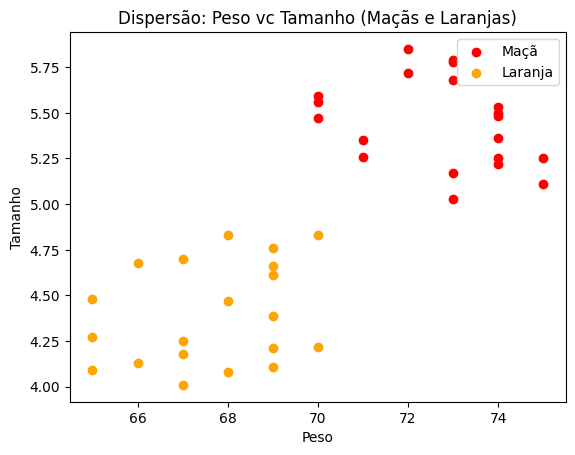

In [100]:
maçãs = df[df['classe'] == 'apple']
laranjas = df[df['classe'] == 'orange']
plt.scatter(maçãs['peso'], maçãs['tamanho'], color='red', label='Maçã')
plt.scatter(laranjas['peso'], laranjas['tamanho'], color='orange', label='Laranja')
plt.xlabel('Peso')
plt.ylabel('Tamanho')
plt.title('Dispersão: Peso vc Tamanho (Maçãs e Laranjas)')
plt.legend()
plt.show()


Em seguida foi separada as colunas peso e tamanho como variáveis de X e a coluna classe como variável Y

In [101]:
x = df.iloc[:,0:2]
y = df.iloc[:,2]

Foi reservado 20% da base para teste, restando 80% para treino, resultando então em 32 registros para treinar o modelo e 8 registros para avaliação.

In [102]:
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=0)

Foi aplicada a normalização com o StandardScaler() conforme também utilizado na aula do exercício Pima Indians. A normalização aplicada para evitar que o modelo  seja influenciado pela diferença de escala entre as variáveis, cujos desvios padrão são 3,03 para o peso e 0,59 para o tamanho, a normalização faz com que ambas as variáveis tenham média 0 e desvio padrão 1. A normalização foi ajustada apenas sobre o conjunto de treino, com o fit_transform e aplicada ao conjunto de teste com o transform.



In [103]:
sc_x = StandardScaler()
x_train = sc_x.fit_transform(x_train)
x_test = sc_x.transform(x_test)

Criado classificador KNN com K = 5, mesmo valor utilizado no exercício da base Pima Indians. O valor ímpar evita empate na votação, já que o problema possui duas classes. O modelo foi treinado com o conjunto de treino e, em seguida, aplicado ao conjunto de teste para gerar as previsões.

In [104]:
classifier = KNeighborsClassifier(n_neighbors=5, p=2, metric='minkowski')
classifier.fit(x_train, y_train)
y_pred = classifier.predict(x_test)

Conforme código mencionado na aula de Regressão, foi montada uma tabela para inspeção qualitativa das previsões, comparando a classe real de cada fruta do conjunto de teste com a classe prevista pelo modelo. As oito previsões coincidiram com o valor real, sem nenhuma divergência. A numeração apresentada na primeira coluna é referente à posição original de cada registro na base, preservadas após o sorteio realizado na divisão entre treino e teste.

In [105]:
comparacao = pd.DataFrame({'Real': y_test, 'Previsto': y_pred})
comparacao

,Real,Previsto
22,orange,orange
20,orange,orange
25,apple,apple
4,orange,orange
10,apple,apple
15,orange,orange
28,apple,apple
11,apple,apple


O modelo acertou as 8 frutas do conjunto de teste, o que dá acurácia de 100%. A matriz de confusão mostra onde esses acertos ficaram: 4 na célula de maçã prevista como maçã e 4 na de laranja prevista como laranja. As outras duas células que registrariam as classificações trocadas ficaram zeradas.

In [106]:
print(accuracy_score(y_test, y_pred))

1.0


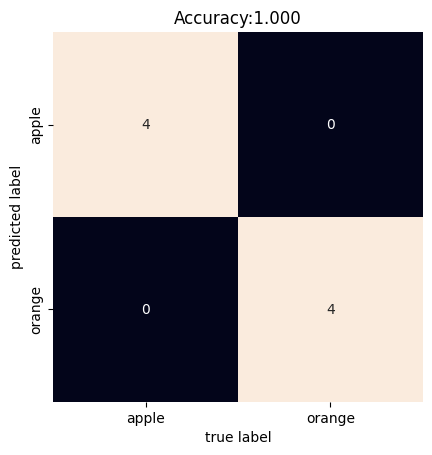

In [107]:
mat = confusion_matrix(y_test, y_pred)
sns.heatmap(mat.T, square=True, annot=True, fmt='d', cbar=False,
xticklabels=['apple','orange'],
yticklabels=['apple','orange'])
plt.title('Accuracy:{0:.3f}'.format(accuracy_score(y_test,y_pred)))
plt.xlabel('true label')
plt.ylabel('predicted label');


Para testar o modelo em dados que ele nunca viu, foi criado quatro frutas fictícias com pesos e tamanhos que não aparecem na base. Antes de classificá-las, foi aplicado o **transform** do mesmo normalizador usado no treino já que o modelo só reconhece valores na escala normalizada.

In [108]:
novos = pd.DataFrame([[68, 4.30],[74,4.65],[70,4.92],[71,5.15]],
                     columns=['peso','tamanho'])
novos_norm = sc_x.transform(novos)
novos['previsao'] = classifier.predict(novos_norm)
novos

,peso,tamanho,previsao
0,68,4.30,orange
1,74,4.65,apple
2,70,4.92,orange
3,71,5.15,apple


As previsões laranja para (68;4,30), maçã para (74;4,65), laranja para (70;4,92) e maçã para (71;5,15).
O primeiro e o último ponto pertencem às regiões de cada classe no gráfico de dispersão, e a classificação seguiu essa leitura. Os outros dois testam o modelo.
- A fruta de peso 74 e tamanho 4,65 tem peso de maçã e tamanho de laranja, combinação que não existe na base, e foi classificada como maçã.
- Em (70;4,92) o tamanho supera 4,83, que é o máximo entre as laranjas, e a classificação permaneceu laranja.

Isso demonstra que o modelo analisa o peso e o tamanho em conjunto, e não apenas uma variável isolada.
